In [50]:
import pandas as pd
import polars as pl
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt


In [51]:
def plot_hist(y_pred, y_test, filename):
    plt.figure(figsize=(8, 6))
    plt.hist(y_pred, bins = 30, alpha=0.6, label = 'Predictions')
    plt.hist(y_test, bins = 30, alpha=0.6, label = 'Actual')
    plt.title("Predict vs Test")
    plt.xlabel(filename)
    plt.legend()
    #plt.savefig(f'../../img/{filename}-his.png')
    plt.show() 

In [52]:
def plot_residuals(y_pred, residuals):
    plt.figure(figsize=(8, 6))
    plt.scatter(y_pred, residuals, alpha=0.6) 
    plt.axhline(0, color='red', linestyle='--') 
    plt.xlabel("Predicted")
    plt.ylabel("Residuals")
    plt.title("Residual Plot")
    plt.legend()
    #plt.savefig(f'../../img/{filename}-res.png')
    plt.show()

In [53]:
df = pd.read_csv('data/grad.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   admit   400 non-null    int64  
 1   gre     400 non-null    int64  
 2   gpa     400 non-null    float64
 3   rank    400 non-null    int64  
dtypes: float64(1), int64(3)
memory usage: 12.6 KB


In [54]:
X = df[['gre', 'gpa', 'rank']]
y = df['admit']

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)
numeric_transformer = Pipeline(steps=[
    ("scaler", MinMaxScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, X.columns)
])

model_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression())
])
model_pipeline.fit(X_train, y_train)
score = model_pipeline.score(X_test, y_test)
print(f"Test Accuracy Score: {score:.4f}")

Test Accuracy Score: 0.6750


In [56]:
pdf = pl.read_csv('data/grad.csv')

In [57]:
Xp = pdf[['gre', 'gpa', 'rank']]
yp = pdf['admit']

In [58]:
Xp_train, Xp_test, yp_train, yp_test = train_test_split(
Xp, yp, test_size=0.2, random_state=42
)
numeric_transformer = Pipeline(steps=[
    ("scaler", MinMaxScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, Xp.columns)
])

model_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression())
])
model_pipeline.fit(Xp_train, yp_train)
score = model_pipeline.score(X_test, y_test)
print(f"Test Accuracy Score: {score:.4f}")

Test Accuracy Score: 0.6750


In [59]:
yp_pred = model_pipeline.predict(Xp_test)

In [60]:
yp_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0])

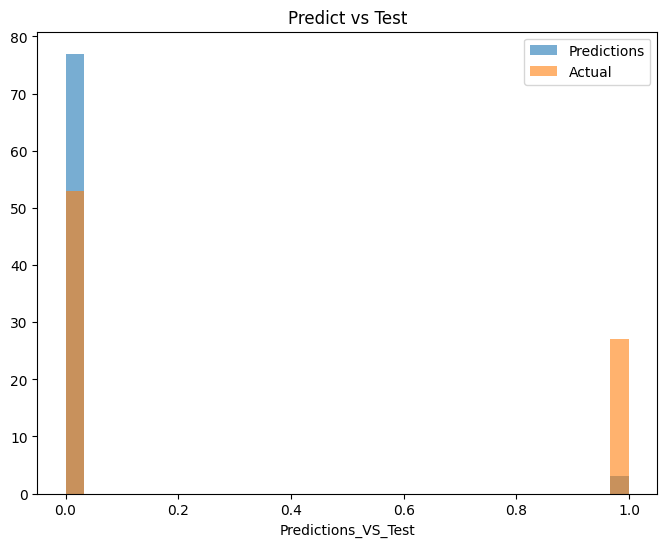

In [61]:
plot_hist(yp_pred, yp_test, 'Predictions_VS_Test')

In [64]:
df = pl.read_csv('data/titanic_survival.csv')

In [87]:
df.columns

['survived',
 'pclass',
 'sex',
 'age',
 'sibsp',
 'parch',
 'fare',
 'embarked',
 'class',
 'who',
 'adult_male',
 'deck',
 'embark_town',
 'alive',
 'alone']

In [88]:
X = df[['age', 'sex']]
y = df['survived'] 

In [92]:
cats = X['sex'].to_dummies(drop_first=True)

In [94]:
dummies = pl.concat([X, cats], how='horizontal')

In [95]:
dummies

age,sex,sex_female
f64,str,u8
22.0,"""male""",0
38.0,"""female""",1
26.0,"""female""",1
35.0,"""female""",1
35.0,"""male""",0
…,…,…
27.0,"""male""",0
19.0,"""female""",1
null,"""female""",1


In [93]:
cats

sex_female
u8
0
1
1
1
0
…
0
1
1


In [81]:
y.value_counts()

survived,count
i64,u32
1,342
0,549


In [83]:
X = X.with_columns(pl.col('age').fill_nan(None).fill_null(strategy='mean'))

In [84]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [85]:
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [86]:
model.score(X_test, y_test)

0.57847533632287